In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")

print("Path to dataset files:", path)
# load the dataset
import pandas as pd
life = pd.read_csv(path + "/Life Expectancy Data.csv")

# upload file from your lapotp
# load the poverty datset
poverty = pd.read_csv('poverty.csv')

100%|██████████| 119k/119k [00:00<00:00, 401kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kumarajarshi/life-expectancy-who/versions/1


In [4]:
life

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [5]:
life.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [6]:
life = life.filter(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality','GDP','Population','Income composition of resources'])
life

,Country,Year,Status,Life expectancy,Adult Mortality,GDP,Population,Income composition of resources
0,Afghanistan,2015,Developing,65.0,263.0,584.259210,33736494.0,0.479
1,Afghanistan,2014,Developing,59.9,271.0,612.696514,327582.0,0.476
2,Afghanistan,2013,Developing,59.9,268.0,631.744976,31731688.0,0.470
3,Afghanistan,2012,Developing,59.5,272.0,669.959000,3696958.0,0.463
4,Afghanistan,2011,Developing,59.2,275.0,63.537231,2978599.0,0.454
...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,454.366654,12777511.0,0.407
2934,Zimbabwe,2003,Developing,44.5,715.0,453.351155,12633897.0,0.418
2935,Zimbabwe,2002,Developing,44.8,73.0,57.348340,125525.0,0.427
2936,Zimbabwe,2001,Developing,45.3,686.0,548.587312,12366165.0,0.427


In [7]:
life.rename(columns={'Income composition of resources': 'Income'}, inplace=True)

Text(0, 0.5, 'Life expectancy')

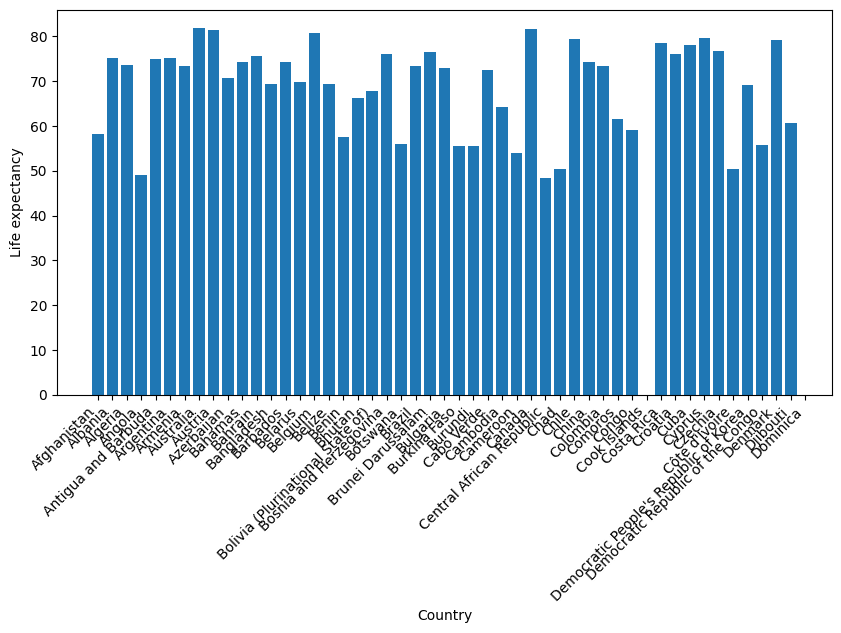

In [8]:
# average life expectancy for all years by country
life_exp = life.groupby(['Country'])['Life expectancy '].mean()
#life_exp.sort_values(ascending=False, inplace=True)
life_exp
# plot top countries with high life expectancy
plt.figure(figsize=(10,5))
plt.bar(life_exp.index[:50], life_exp.values[:50])
plt.xticks(rotation =45, ha='right')
plt.xlabel('Country')
plt.ylabel('Life expectancy')


In [ ]:
life_exp.describe()

,Life expectancy
count,183.000000
mean,69.224932
std,9.186432
min,46.112500
25%,62.475000
50%,72.487500
75%,75.106250
max,82.537500


In [ ]:
poverty

,Country,Year,poverty
0,Albania,1996,0.534846
1,Albania,2002,1.092647
2,Albania,2005,0.591086
3,Albania,2008,0.199925
4,Albania,2012,0.620691
...,...,...,...
2700,Zambia,2015,60.793095
2701,Zambia,2022,64.349754
2702,Zimbabwe,2011,21.580000
2703,Zimbabwe,2017,34.206043


In [8]:
# change column name of 'Entity' to 'Country' in poverty dataset
poverty.rename(columns={'Share below $2.15 a day': 'poverty'}, inplace=True)

In [9]:
# merge datasets on country and year
life_pov = pd.merge(life, poverty, on=['Country', 'Year'])

In [10]:
life_pov

,Country,Year,Status,Life expectancy,Adult Mortality,GDP,Population,Income,poverty
0,Albania,2015,Developing,77.8,74.0,3954.227830,28873.0,0.762,0.096067
1,Albania,2014,Developing,77.5,8.0,4575.763787,288914.0,0.761,1.023101
2,Albania,2012,Developing,76.9,86.0,4247.614380,2941.0,0.752,0.620691
3,Albania,2008,Developing,75.3,1.0,437.539647,2947314.0,0.713,0.199925
4,Albania,2005,Developing,73.5,15.0,279.142931,311487.0,0.685,0.591086
...,...,...,...,...,...,...,...,...,...
980,Zambia,2010,Developing,58.0,363.0,1463.213573,138533.0,0.533,64.401900
981,Zambia,2006,Developing,58.0,526.0,13.154199,12383446.0,0.479,64.698030
982,Zambia,2004,Developing,47.9,578.0,53.277222,11731746.0,0.456,61.062454
983,Zambia,2002,Developing,45.5,69.0,377.135244,111249.0,0.433,56.388855


In [11]:
import pandas as pd
import requests

# Fetch the data.
income_ineq = pd.read_csv("https://ourworldindata.org/grapher/economic-inequality-gini-index.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/economic-inequality-gini-index.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

income_ineq = income_ineq.drop(columns=['990179-annotations'])

In [12]:
income_ineq.drop(columns=['Code'], inplace=True)

In [13]:
import pandas as pd
import requests

# Fetch the data.
sanitation = pd.read_csv("https://ourworldindata.org/grapher/share-using-safely-managed-sanitation.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/share-using-safely-managed-sanitation.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

sanitation

,Entity,Code,Year,san_sm__residence_total
0,Africa (WHO),NaN,2000,18.876840
1,Africa (WHO),NaN,2001,19.076805
2,Africa (WHO),NaN,2002,19.366491
3,Africa (WHO),NaN,2003,19.655367
4,Africa (WHO),NaN,2004,19.947477
...,...,...,...,...
3648,Zimbabwe,ZWE,2018,33.544266
3649,Zimbabwe,ZWE,2019,32.961483
3650,Zimbabwe,ZWE,2020,32.381233
3651,Zimbabwe,ZWE,2021,31.802437


In [14]:
sanitation.drop(columns=['Code'], inplace=True)

In [15]:
income_san = pd.merge(sanitation, income_ineq, on=['Year','Entity'])
income_san

,Entity,Year,san_sm__residence_total,gini
0,Albania,2002,27.769495,0.317390
1,Albania,2005,29.693571,0.305957
2,Albania,2008,32.118214,0.299847
3,Albania,2012,35.025410,0.289605
4,Albania,2014,39.372080,0.345989
...,...,...,...,...
1309,Yemen,2005,23.484985,0.347323
1310,Yemen,2014,17.806700,0.367071
1311,Zimbabwe,2011,27.700127,0.431536
1312,Zimbabwe,2017,33.586600,0.443371


In [16]:
income_san.rename(columns={'Entity': 'Country'}, inplace=True)

In [17]:
# merge datasets on country and year
all_df = pd.merge(life_pov, income_san, on=['Country', 'Year'])
all_df

,Country,Year,Status,Life expectancy,Adult Mortality,GDP,Population,Income,poverty,san_sm__residence_total,gini
0,Albania,2015,Developing,77.8,74.0,3954.227830,28873.0,0.762,0.096067,41.580208,0.327537
1,Albania,2014,Developing,77.5,8.0,4575.763787,288914.0,0.761,1.023101,39.372080,0.345989
2,Albania,2012,Developing,76.9,86.0,4247.614380,2941.0,0.752,0.620691,35.025410,0.289605
3,Albania,2008,Developing,75.3,1.0,437.539647,2947314.0,0.713,0.199925,32.118214,0.299847
4,Albania,2005,Developing,73.5,15.0,279.142931,311487.0,0.685,0.591086,29.693571,0.305957
...,...,...,...,...,...,...,...,...,...,...,...
812,Uzbekistan,2002,Developing,67.1,186.0,383.349500,2527185.0,0.600,80.469690,74.150450,0.330365
813,Uzbekistan,2000,Developing,67.1,189.0,558.221144,24654.0,0.000,81.342990,74.167270,0.360116
814,Yemen,2014,Developing,65.4,228.0,NaN,NaN,0.500,19.802757,17.806700,0.367071
815,Yemen,2005,Developing,62.6,245.0,NaN,NaN,0.470,10.542901,23.484985,0.347323


In [18]:
# prompt: rename all_df columns '$30.00 per day - share of population below poverty line' to 'poverty'

all_df.rename(columns={'san_sm__residence_total':'sanitation'}, inplace=True)


In [19]:
all_df

,Country,Year,Status,Life expectancy,Adult Mortality,GDP,Population,Income,poverty,sanitation,gini
0,Albania,2015,Developing,77.8,74.0,3954.227830,28873.0,0.762,0.096067,41.580208,0.327537
1,Albania,2014,Developing,77.5,8.0,4575.763787,288914.0,0.761,1.023101,39.372080,0.345989
2,Albania,2012,Developing,76.9,86.0,4247.614380,2941.0,0.752,0.620691,35.025410,0.289605
3,Albania,2008,Developing,75.3,1.0,437.539647,2947314.0,0.713,0.199925,32.118214,0.299847
4,Albania,2005,Developing,73.5,15.0,279.142931,311487.0,0.685,0.591086,29.693571,0.305957
...,...,...,...,...,...,...,...,...,...,...,...
812,Uzbekistan,2002,Developing,67.1,186.0,383.349500,2527185.0,0.600,80.469690,74.150450,0.330365
813,Uzbekistan,2000,Developing,67.1,189.0,558.221144,24654.0,0.000,81.342990,74.167270,0.360116
814,Yemen,2014,Developing,65.4,228.0,NaN,NaN,0.500,19.802757,17.806700,0.367071
815,Yemen,2005,Developing,62.6,245.0,NaN,NaN,0.470,10.542901,23.484985,0.347323


In [20]:
# UPLOAD CSV FILE FROM LAPTOP
fertility = pd.read_csv('child_per.csv.csv')
fertility = fertility.drop(columns='Code')
fertility.rename(columns={'Fertility rate - Sex: all - Age: all - Variant: estimates': 'Fertility'}, inplace=True)
fertility.rename(columns={'Entity': 'Country'}, inplace=True)
fertility


,Country,Year,Fertility
0,Afghanistan,1950,7.248
1,Afghanistan,1951,7.260
2,Afghanistan,1952,7.260
3,Afghanistan,1953,7.266
4,Afghanistan,1954,7.254
...,...,...,...
18717,Zimbabwe,2019,3.748
18718,Zimbabwe,2020,3.754
18719,Zimbabwe,2021,3.765
18720,Zimbabwe,2022,3.767


In [21]:
all_df = pd.merge(all_df, fertility, on=['Country', 'Year'])
all_df

,Country,Year,Status,Life expectancy,Adult Mortality,GDP,Population,Income,poverty,sanitation,gini,Fertility
0,Albania,2015,Developing,77.8,74.0,3954.227830,28873.0,0.762,0.096067,41.580208,0.327537,1.631
1,Albania,2014,Developing,77.5,8.0,4575.763787,288914.0,0.761,1.023101,39.372080,0.345989,1.721
2,Albania,2012,Developing,76.9,86.0,4247.614380,2941.0,0.752,0.620691,35.025410,0.289605,1.719
3,Albania,2008,Developing,75.3,1.0,437.539647,2947314.0,0.713,0.199925,32.118214,0.299847,1.616
4,Albania,2005,Developing,73.5,15.0,279.142931,311487.0,0.685,0.591086,29.693571,0.305957,1.787
...,...,...,...,...,...,...,...,...,...,...,...,...
812,Uzbekistan,2002,Developing,67.1,186.0,383.349500,2527185.0,0.600,80.469690,74.150450,0.330365,2.575
813,Uzbekistan,2000,Developing,67.1,189.0,558.221144,24654.0,0.000,81.342990,74.167270,0.360116,2.696
814,Yemen,2014,Developing,65.4,228.0,NaN,NaN,0.500,19.802757,17.806700,0.367071,4.620
815,Yemen,2005,Developing,62.6,245.0,NaN,NaN,0.470,10.542901,23.484985,0.347323,5.563


In [22]:
all_df = all_df.dropna()
all_df

,Country,Year,Status,Life expectancy,Adult Mortality,GDP,Population,Income,poverty,sanitation,gini,Fertility
0,Albania,2015,Developing,77.8,74.0,3954.227830,28873.0,0.762,0.096067,41.580208,0.327537,1.631
1,Albania,2014,Developing,77.5,8.0,4575.763787,288914.0,0.761,1.023101,39.372080,0.345989,1.721
2,Albania,2012,Developing,76.9,86.0,4247.614380,2941.0,0.752,0.620691,35.025410,0.289605,1.719
3,Albania,2008,Developing,75.3,1.0,437.539647,2947314.0,0.713,0.199925,32.118214,0.299847,1.616
4,Albania,2005,Developing,73.5,15.0,279.142931,311487.0,0.685,0.591086,29.693571,0.305957,1.787
...,...,...,...,...,...,...,...,...,...,...,...,...
809,Ukraine,2002,Developing,67.6,256.0,879.475486,48225.0,0.683,2.662997,42.896427,0.290457,1.127
811,Uzbekistan,2003,Developing,67.2,183.0,396.129969,2556765.0,0.607,81.503525,74.125740,0.352610,2.503
812,Uzbekistan,2002,Developing,67.1,186.0,383.349500,2527185.0,0.600,80.469690,74.150450,0.330365,2.575
813,Uzbekistan,2000,Developing,67.1,189.0,558.221144,24654.0,0.000,81.342990,74.167270,0.360116,2.696


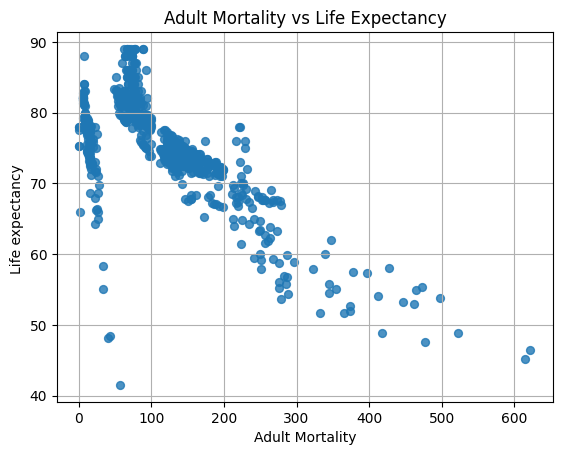

In [58]:
all_df.plot(kind='scatter', x='Adult Mortality', y='Life expectancy ', s=32, alpha=.8)
plt.grid(True)

plt.title('Adult Mortality vs Life Expectancy')
plt.show()

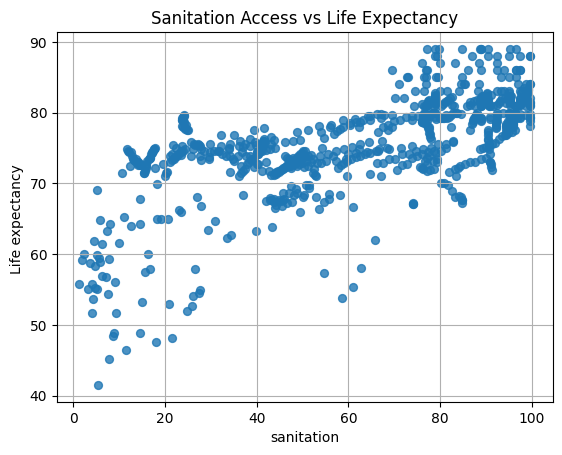

In [60]:
all_df.plot(kind='scatter', x='sanitation', y='Life expectancy ', s=32, alpha=.8)
plt.grid(True)

plt.title('Sanitation Access vs Life Expectancy')
plt.show()

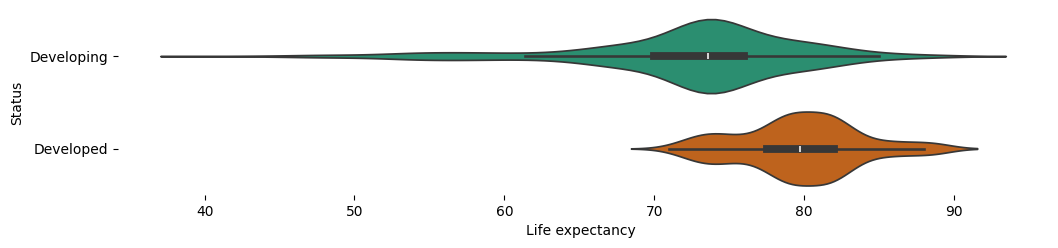

In [23]:
# @title Status vs Life expectancy

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(all_df['Status'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(all_df, x='Life expectancy ', y='Status', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

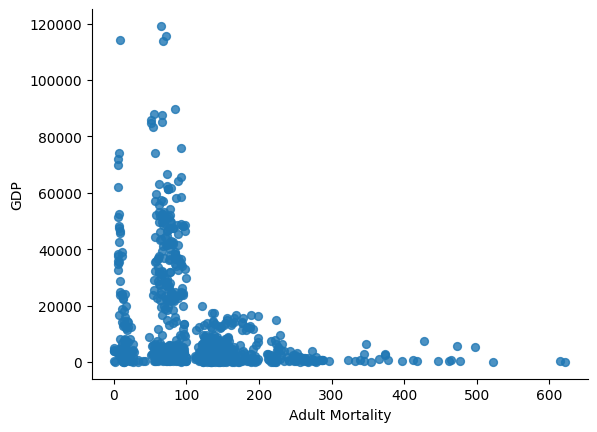

In [ ]:
# @title Adult Mortality vs GDP

from matplotlib import pyplot as plt
all_df.plot(kind='scatter', x='Adult Mortality', y='GDP', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

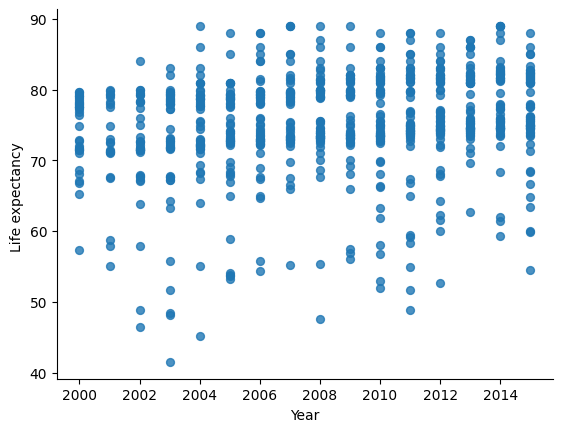

In [ ]:
# @title Year vs Life expectancy

from matplotlib import pyplot as plt
all_df.plot(kind='scatter', x='Year', y='Life expectancy ', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [38]:
# check for multicollinearity for the dataframe 'all_df'

from statsmodels.stats.outliers_influence import variance_inflation_factor

# among the numerical features.  Replace with your actual column names.
numerical_cols = ['Adult Mortality', 'poverty', 'sanitation','GDP','Population']


# Create a new dataframe with only the numerical features
X = all_df[numerical_cols]

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Print or display the VIF values
vif_data


,feature,VIF
0,Adult Mortality,3.321294
1,poverty,2.021655
2,sanitation,3.427331
3,GDP,2.057965
4,Population,1.077861


In [ ]:
all_df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'GDP', 'Population', 'Income', 'poverty', 'sanitation', 'gini',
       'Fertility'],
      dtype='object')

# decision tree

In [43]:
# make a decision tree that shows if a country is developed or undeveloped by 'Status' using columns :  'poverty', 'sanitation', 'GDP',' Population'

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import export_text

# Prepare the data
features = ['poverty', 'sanitation', 'Population']
X = all_df[features]
y = all_df['Status']

# Convert categorical features to numerical (if needed)
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42) # Limiting depth for better visualization
clf = clf.fit(X_train,y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model (optional)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

# Visualize the decision tree
#tree_rules = export_text(clf, feature_names=list(X.columns))
#tree_rules


Accuracy: 0.8758169934640523


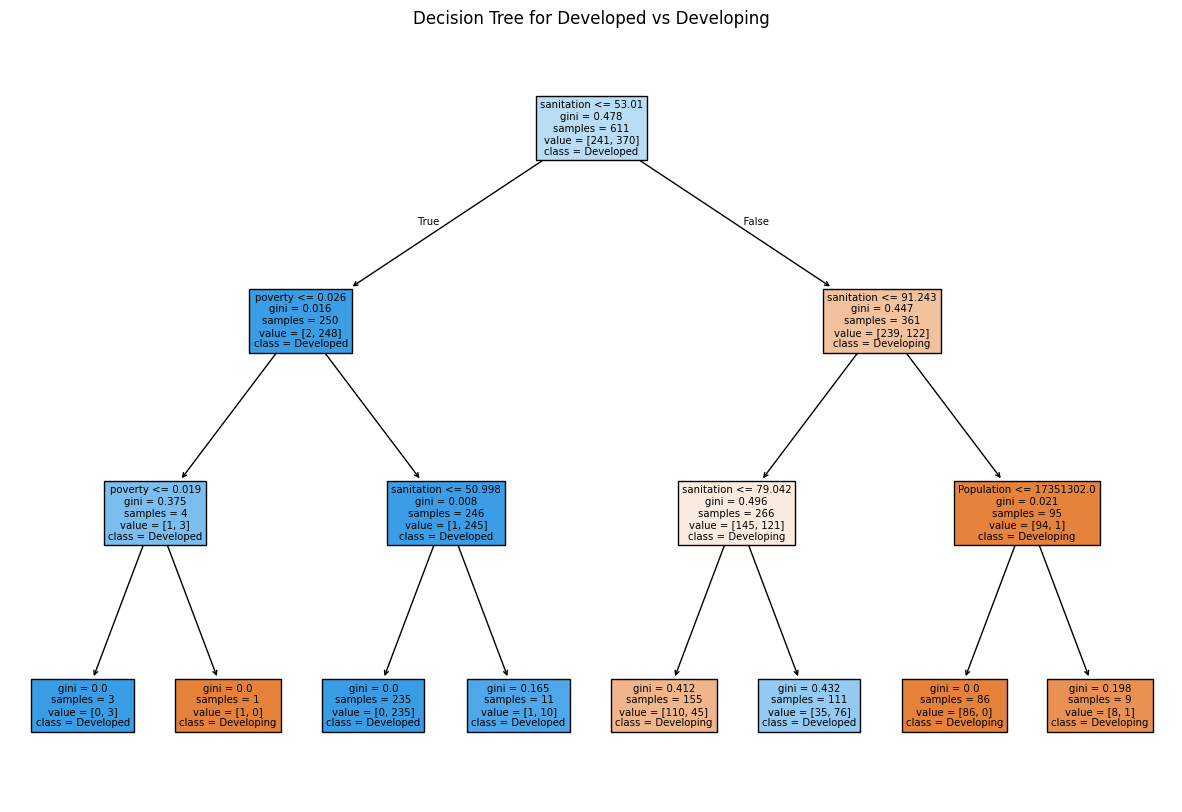

In [44]:
# plot the decision tree from code above

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(clf, filled=True, feature_names=list(X.columns), class_names=['Developing', 'Developed'])
# include title
plt.title("Decision Tree for Developed vs Developing")
plt.show()


In [45]:
all_df

,Country,Year,Status,Life expectancy,Adult Mortality,GDP,Population,Income,poverty,sanitation,gini,Fertility
0,Albania,2015,Developing,77.8,74.0,3954.227830,28873.0,0.762,0.096067,41.580208,0.327537,1.631
1,Albania,2014,Developing,77.5,8.0,4575.763787,288914.0,0.761,1.023101,39.372080,0.345989,1.721
2,Albania,2012,Developing,76.9,86.0,4247.614380,2941.0,0.752,0.620691,35.025410,0.289605,1.719
3,Albania,2008,Developing,75.3,1.0,437.539647,2947314.0,0.713,0.199925,32.118214,0.299847,1.616
4,Albania,2005,Developing,73.5,15.0,279.142931,311487.0,0.685,0.591086,29.693571,0.305957,1.787
...,...,...,...,...,...,...,...,...,...,...,...,...
809,Ukraine,2002,Developing,67.6,256.0,879.475486,48225.0,0.683,2.662997,42.896427,0.290457,1.127
811,Uzbekistan,2003,Developing,67.2,183.0,396.129969,2556765.0,0.607,81.503525,74.125740,0.352610,2.503
812,Uzbekistan,2002,Developing,67.1,186.0,383.349500,2527185.0,0.600,80.469690,74.150450,0.330365,2.575
813,Uzbekistan,2000,Developing,67.1,189.0,558.221144,24654.0,0.000,81.342990,74.167270,0.360116,2.696


# model

In [26]:
all_df.Year.value_counts()

,count
Year,
2015,59
2011,58
2010,58
2012,57
2008,53
2013,53
2014,53
2006,51
2009,50


In [31]:
# prompt: split df 'all_df' in two seperate tables: 1st table with years below 2012, 2nd table with years 2010 and above

# Create the first dataframe with years below 2012
df_below_2012 = all_df[all_df['Year'] < 2012]

# Create the second dataframe with years 2012 and above
df_2012_and_above = all_df[all_df['Year'] >= 2012]

# Now you have two separate dataframes:
# df_below_2010 and df_2010_and_above



In [36]:
df_below_2012

,Country,Year,Status,Life expectancy,Adult Mortality,GDP,Population,Income,poverty,sanitation,gini,Fertility
3,Albania,2008,Developing,75.3,1.0,437.539647,2947314.0,0.713,0.199925,32.118214,0.299847,1.616
4,Albania,2005,Developing,73.5,15.0,279.142931,311487.0,0.685,0.591086,29.693571,0.305957,1.787
5,Albania,2002,Developing,73.3,15.0,1453.642777,3511.0,0.670,1.092647,27.769495,0.317390,2.002
6,Algeria,2011,Developing,74.9,116.0,5432.252300,36819558.0,0.724,0.000000,62.258324,0.276157,2.899
11,Armenia,2011,Developing,73.9,128.0,3526.978143,2875581.0,0.729,1.185071,12.690536,0.293529,1.615
...,...,...,...,...,...,...,...,...,...,...,...,...
809,Ukraine,2002,Developing,67.6,256.0,879.475486,48225.0,0.683,2.662997,42.896427,0.290457,1.127
811,Uzbekistan,2003,Developing,67.2,183.0,396.129969,2556765.0,0.607,81.503525,74.125740,0.352610,2.503
812,Uzbekistan,2002,Developing,67.1,186.0,383.349500,2527185.0,0.600,80.469690,74.150450,0.330365,2.575
813,Uzbekistan,2000,Developing,67.1,189.0,558.221144,24654.0,0.000,81.342990,74.167270,0.360116,2.696


In [35]:
df_2012_and_above

,Country,Year,Status,Life expectancy,Adult Mortality,GDP,Population,Income,poverty,sanitation,gini,Fertility
0,Albania,2015,Developing,77.8,74.0,3954.227830,28873.0,0.762,0.096067,41.580208,0.327537,1.631
1,Albania,2014,Developing,77.5,8.0,4575.763787,288914.0,0.761,1.023101,39.372080,0.345989,1.721
2,Albania,2012,Developing,76.9,86.0,4247.614380,2941.0,0.752,0.620691,35.025410,0.289605,1.719
7,Armenia,2015,Developing,74.8,118.0,369.654776,291695.0,0.741,1.146360,11.731858,0.323568,1.621
8,Armenia,2014,Developing,74.6,12.0,3994.712355,29622.0,0.739,1.439143,11.983830,0.314833,1.663
...,...,...,...,...,...,...,...,...,...,...,...,...
792,Uganda,2012,Developing,60.0,339.0,647.747410,3636796.0,0.477,37.544044,16.188850,0.410096,5.729
796,Ukraine,2015,Developing,71.3,195.0,2124.662666,4515429.0,0.748,0.123217,64.739890,0.254575,1.387
797,Ukraine,2014,Developing,78.0,23.0,314.658296,45271947.0,0.746,0.012276,62.335735,0.240254,1.466
798,Ukraine,2013,Developing,71.0,198.0,429.715540,454896.0,0.744,0.004415,59.672977,0.245550,1.515


In [39]:
train = df_below_2012.drop(columns=['Country','Year','Status','gini','Fertility'])
test = df_2012_and_above.drop(columns=['Country','Year','Status','gini','Fertility'])

In [41]:
train.columns

Index(['Life expectancy ', 'Adult Mortality', 'GDP', 'Population', 'Income',
       'poverty', 'sanitation'],
      dtype='object')

In [42]:
y_train = train['Life expectancy ']
X_train = train.drop(columns=['Life expectancy '])
y_test = test['Life expectancy ']
X_test = test.drop(columns=['Life expectancy '])

In [49]:
# prompt: create a polynomial regression model using the train and test data

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Create polynomial features
poly = PolynomialFeatures(degree=2) # Example: degree 2 polynomial
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and train the polynomial regression model
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Make predictions
y_pred = poly_reg.predict(X_test_poly)

# Evaluate the model
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")


Mean Squared Error: 3.9782954402584223
R-squared: 0.6026240966977243


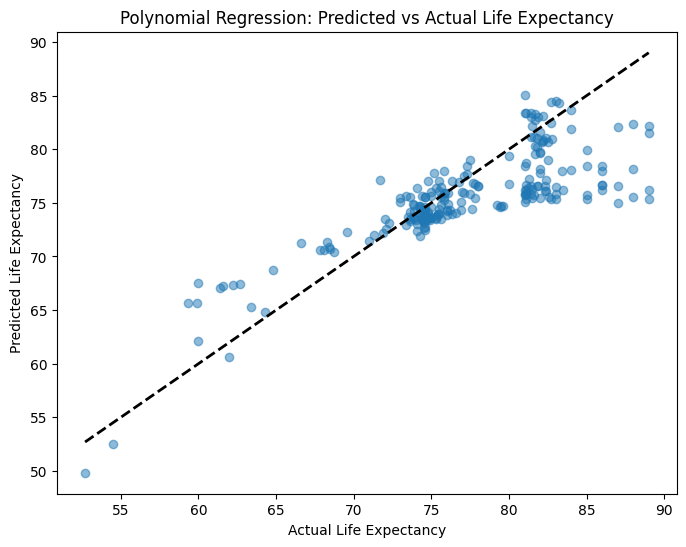

In [50]:
# prompt: plot the polynomial regression model of predicted vs actual values

# Plot predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Polynomial Regression: Predicted vs Actual Life Expectancy')
plt.show()
